In [1]:
%pip install pandas seaborn matplotlib imbalanced-learn scikit-learn scikit-optimize xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.


# Exploratory Data Analysis

In [2]:
import pandas as pd

file_path = r"C:\Users\Jorge Ferreira\Desktop\Credit Risk Prediction\Loan_default.csv"
df = pd.read_csv(file_path)

selected_features = [
    "Age", "Income", "LoanAmount", "CreditScore",
    "MonthsEmployed", "NumCreditLines", "InterestRate"
]
target = "Default"

print("Dataset loaded successfully. First five rows:")
display(df.head())

print(f"Dataset shape: {df.shape[0]:,} rows and {df.shape[1]:,} columns.")

print("Dataset structure, data types, and non-null values:")
df.info()

print("Descriptive statistics for the selected features:")
display(df[selected_features].describe().T)

null_report = pd.DataFrame({
    "Null Count": df[selected_features + [target]].isnull().sum(),
    "Null Percentage": (df[selected_features + [target]].isnull().mean() * 100).round(2)
})
print("Null-value counts and percentages for selected features and target:")
display(null_report)

exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates:,}")

profile_columns = selected_features + [target]
duplicate_profiles = df.duplicated(subset=profile_columns, keep=False).sum()
print(
    f"Rows belonging to duplicated profiles based on the seven selected features "
    f"and {target} (excluding LoanID): {duplicate_profiles:,}"
)

loan_id_unique = df["LoanID"].is_unique
print(f"LoanID is unique: {loan_id_unique}")

default_distribution = pd.DataFrame({
    "Count": df[target].value_counts(),
    "Proportion (%)": (df[target].value_counts(normalize=True) * 100).round(2)
})
print("Default class counts and proportions:")
display(default_distribution)

correlation_matrix = df[selected_features + [target]].corr(numeric_only=True)
print("Correlation matrix for selected numerical features and Default:")
display(correlation_matrix)

correlation_pairs = (
    correlation_matrix.where(
        __import__("numpy").triu(__import__("numpy").ones(correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index(name="Correlation")
    .rename(columns={"level_0": "Feature 1", "level_1": "Feature 2"})
    .sort_values("Correlation", ascending=False)
)

print("Feature correlation pairs sorted in descending order:")
display(correlation_pairs)

Dataset loaded successfully. First five rows:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


Dataset shape: 255,347 rows and 18 columns.
Dataset structure, data types, and non-null values:
<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     2

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0


Null-value counts and percentages for selected features and target:


...

,Count,Proportion (%)
Default,,
0,225694,88.39
1,29653,11.61


Correlation matrix for selected numerical features and Default:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.131273
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,1.000000


Feature correlation pairs sorted in descending order:


,Feature 1,Feature 2,Correlation
55,InterestRate,Default,0.131273
23,LoanAmount,Default,0.086659
47,NumCreditLines,Default,0.028330
20,LoanAmount,MonthsEmployed,0.002817
12,Income,MonthsEmployed,0.002675
...,...,...,...
59,Default,CreditScore,NaN
60,Default,MonthsEmployed,NaN
61,Default,NumCreditLines,NaN
62,Default,InterestRate,NaN


# Feature Engineering

,Full dataset,Training set,Test set
Default,,,
0,225694,180555,45139
1,29653,23722,5931


,Full dataset,Training set,Test set
Default,,,
0,88.39,88.39,88.39
1,11.61,11.61,11.61


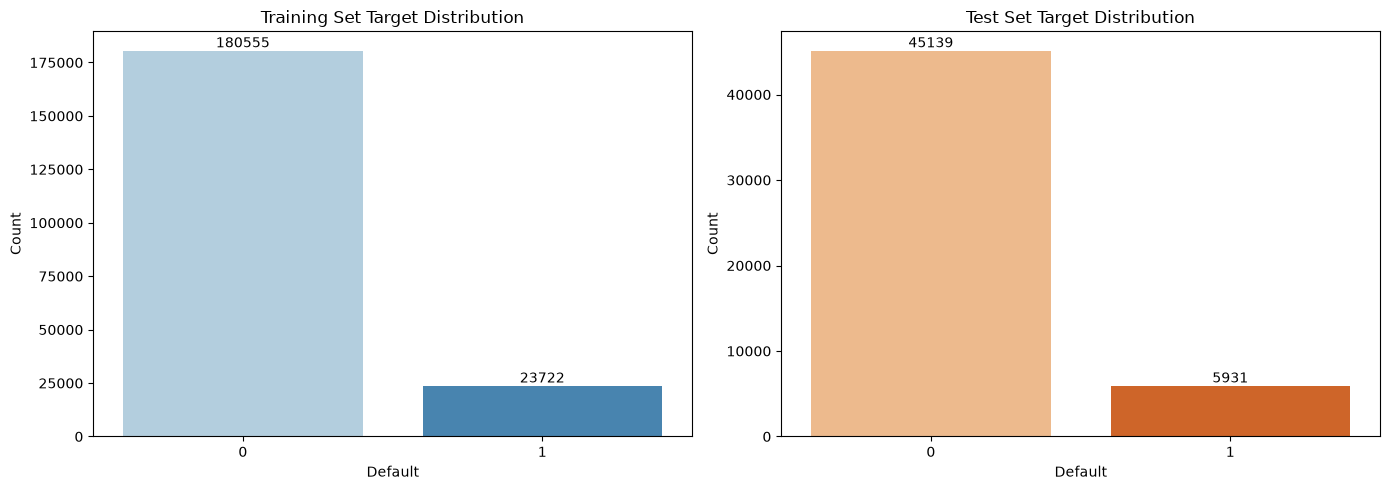

In [3]:
from sklearn.model_selection import train_test_split
import seaborn as sns

import matplotlib.pyplot as plt

X = df[selected_features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

target_distributions = pd.DataFrame({
    "Full dataset": y.value_counts(normalize=True).mul(100).round(2),
    "Training set": y_train.value_counts(normalize=True).mul(100).round(2),
    "Test set": y_test.value_counts(normalize=True).mul(100).round(2)
})

target_counts = pd.DataFrame({
    "Full dataset": y.value_counts(),
    "Training set": y_train.value_counts(),
    "Test set": y_test.value_counts()
})

display(target_counts)
display(target_distributions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_train, ax=axes[0], hue=y_train, palette="Blues", legend=False)
axes[0].set_title("Training Set Target Distribution")
axes[0].set_xlabel("Default")
axes[0].set_ylabel("Count")

sns.countplot(x=y_test, ax=axes[1], hue=y_test, palette="Oranges", legend=False)
axes[1].set_title("Test Set Target Distribution")
axes[1].set_xlabel("Default")
axes[1].set_ylabel("Count")

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

# Model Development

In [4]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import time

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score
)

print("=" * 90)
print("CROSS-VALIDATED MODEL DEVELOPMENT")
print("=" * 90)
print("Pipeline order: StandardScaler → SMOTE(sampling_strategy=0.5) → Model")
print("GridSearchCV receives the original X_train and y_train only.")
print("Scoring metric: Average Precision (PR-AUC)")
print("Cross-validation: StratifiedKFold(n_splits=3, shuffle=True, random_state=42)")
print("=" * 90)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models_and_grids = [
    (
        "Logistic Regression",
        LogisticRegression(max_iter=3000, random_state=42),
        {
            "model__C": [0.1, 1.0, 10.0],
            "model__solver": ["liblinear", "lbfgs"]
        }
    ),
    (
        "Linear SVC",
        LinearSVC(max_iter=5000, random_state=42),
        {
            "model__C": [0.01, 0.1, 1.0, 10.0],
            "model__class_weight": [None, "balanced"]
        }
    ),
    (
        "Decision Tree",
        DecisionTreeClassifier(random_state=42),
        {
            "model__max_depth": [3, 6, None],
            "model__min_samples_split": [2, 10],
            "model__min_samples_leaf": [1, 5]
        }
    ),
    (
        "Random Forest",
        RandomForestClassifier(random_state=42, n_jobs=1),
        {
            "model__n_estimators": [200],
            "model__max_depth": [None, 10],
            "model__min_samples_leaf": [1, 5],
            "model__max_features": ["sqrt"]
        }
    ),
    (
        "LightGBM",
        LGBMClassifier(random_state=42, n_jobs=1, verbosity=-1),
        {
            "model__n_estimators": [200],
            "model__learning_rate": [0.05, 0.1],
            "model__num_leaves": [15, 31],
            "model__max_depth": [-1, 8]
        }
    ),
    (
        "XGBoost",
        XGBClassifier(
            random_state=42,
            n_jobs=1,
            eval_metric="logloss",
            tree_method="hist"
        ),
        {
            "model__n_estimators": [200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 6],
            "model__subsample": [0.8, 1.0]
        }
    ),
    (
        "CatBoost",
        CatBoostClassifier(
            random_state=42,
            thread_count=1,
            verbose=0,
            allow_writing_files=False
        ),
        {
            "model__iterations": [200],
            "model__learning_rate": [0.05, 0.1],
            "model__depth": [4, 6],
            "model__l2_leaf_reg": [3, 5]
        }
    ),
    (
        "AdaBoost",
        AdaBoostClassifier(random_state=42),
        {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1, 1.0]
        }
    )
]

results = []
best_models = {}

for model_name, model, param_grid in models_and_grids:
    print(f"\n{'─' * 90}")
    print(f"Training: {model_name}")
    print(f"Hyperparameter combinations: {len(list(ParameterGrid(param_grid)))}")
    print("Running 3-fold stratified GridSearchCV...")

    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
        ("model", model)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False
    )

    start_time = time.perf_counter()
    grid_search.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time

    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model

    y_pred = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_test)[:, 1]
    else:
        y_score = best_model.decision_function(X_test)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    test_pr_auc = average_precision_score(y_test, y_score)
    test_roc_auc = roc_auc_score(y_test, y_score)

    best_cv_std = grid_search.cv_results_["std_test_score"][grid_search.best_index_]

    print(f"Best hyperparameters: {grid_search.best_params_}")
    print(f"Best CV PR-AUC:      {grid_search.best_score_:.4f} ± {best_cv_std:.4f}")
    print(f"Training time:       {training_time:.2f} seconds")
    print(f"Test Precision:      {precision:.4f}")
    print(f"Test Recall:         {recall:.4f}")
    print(f"Test F1-Score:       {f1:.4f}")
    print(f"Test PR-AUC:         {test_pr_auc:.4f}")
    print(f"Test ROC-AUC:        {test_roc_auc:.4f}")

    results.append({
        "Model": model_name,
        "Best Hyperparameters": grid_search.best_params_,
        "CV PR-AUC": grid_search.best_score_,
        "CV PR-AUC Std": best_cv_std,
        "Training Time (sec)": training_time,
        "Test Precision": precision,
        "Test Recall": recall,
        "Test F1-Score": f1,
        "Test PR-AUC": test_pr_auc,
        "Test ROC-AUC": test_roc_auc
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Test PR-AUC", ascending=False)
    .reset_index(drop=True)
)

print(f"\n{'=' * 90}")
print("FINAL MODEL COMPARISON — SORTED BY TEST PR-AUC")
print(f"{'=' * 90}")

print(
    results_df.to_string(
        index=False,
        formatters={
            "CV PR-AUC": "{:.4f}".format,
            "CV PR-AUC Std": "{:.4f}".format,
            "Training Time (sec)": "{:.2f}".format,
            "Test Precision": "{:.4f}".format,
            "Test Recall": "{:.4f}".format,
            "Test F1-Score": "{:.4f}".format,
            "Test PR-AUC": "{:.4f}".format,
            "Test ROC-AUC": "{:.4f}".format
        }
    )
)

print(f"\nBest model by Test PR-AUC: {results_df.loc[0, 'Model']}")
print(f"Best Test PR-AUC: {results_df.loc[0, 'Test PR-AUC']:.4f}")

CROSS-VALIDATED MODEL DEVELOPMENT
Pipeline order: StandardScaler → SMOTE(sampling_strategy=0.5) → Model
GridSearchCV receives the original X_train and y_train only.
Scoring metric: Average Precision (PR-AUC)
Cross-validation: StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

──────────────────────────────────────────────────────────────────────────────────────────
Training: Logistic Regression
Hyperparameter combinations: 6
Running 3-fold stratified GridSearchCV...
Best hyperparameters: {'model__C': 0.1, 'model__solver': 'lbfgs'}
Best CV PR-AUC:      0.2856 ± 0.0034
Training time:       14.67 seconds
Test Precision:      0.3064
Test Recall:         0.4036
Test F1-Score:       0.3483
Test PR-AUC:         0.2923
Test ROC-AUC:        0.7420

──────────────────────────────────────────────────────────────────────────────────────────
Training: Linear SVC
Hyperparameter combinations: 8
Running 3-fold stratified GridSearchCV...
Best hyperparameters: {'model__C': 0.01, 'model__class_w

AttributeError: The '.style' accessor requires jinja2

In [5]:
print(f"\n{'=' * 90}")
print("FINAL MODEL COMPARISON — SORTED BY TEST PR-AUC")
print(f"{'=' * 90}")

print(
    results_df.to_string(
        index=False,
        formatters={
            "CV PR-AUC": "{:.4f}".format,
            "CV PR-AUC Std": "{:.4f}".format,
            "Training Time (sec)": "{:.2f}".format,
            "Test Precision": "{:.4f}".format,
            "Test Recall": "{:.4f}".format,
            "Test F1-Score": "{:.4f}".format,
            "Test PR-AUC": "{:.4f}".format,
            "Test ROC-AUC": "{:.4f}".format
        }
    )
)

print(f"\nBest model by Test PR-AUC: {results_df.loc[0, 'Model']}")
print(f"Best Test PR-AUC: {results_df.loc[0, 'Test PR-AUC']:.4f}")


FINAL MODEL COMPARISON — SORTED BY TEST PR-AUC
              Model                                                                                              Best Hyperparameters CV PR-AUC CV PR-AUC Std Training Time (sec) Test Precision Test Recall Test F1-Score Test PR-AUC Test ROC-AUC
           CatBoost               {'model__depth': 6, 'model__iterations': 200, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.1}    0.3020        0.0044              120.63         0.5605      0.0813        0.1420      0.3140       0.7453
            XGBoost        {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}    0.2937        0.0049               37.80         0.3494      0.3072        0.3270      0.3073       0.7431
           LightGBM        {'model__learning_rate': 0.1, 'model__max_depth': -1, 'model__n_estimators': 200, 'model__num_leaves': 31}    0.2961        0.0064               33.21         0.5234      0.0905        0.1544  


Logistic Regression
Precision: 0.3064
Recall:    0.4036
F1-Score:  0.3483
ROC-AUC:   0.7420
PR-AUC:    0.2923
Calculating permutation importance...

Linear SVC
Precision: 0.3125
Recall:    0.3856
F1-Score:  0.3452
ROC-AUC:   0.7420
PR-AUC:    0.2924
Calculating permutation importance...

Decision Tree
Precision: 0.3041
Recall:    0.3215
F1-Score:  0.3126
ROC-AUC:   0.7201
PR-AUC:    0.2676
Calculating permutation importance...

Random Forest
Precision: 0.3360
Recall:    0.3416
F1-Score:  0.3388
ROC-AUC:   0.7429
PR-AUC:    0.3065
Calculating permutation importance...

LightGBM
Precision: 0.5234
Recall:    0.0905
F1-Score:  0.1544
ROC-AUC:   0.7419
PR-AUC:    0.3072
Calculating permutation importance...

XGBoost
Precision: 0.3494
Recall:    0.3072
F1-Score:  0.3270
ROC-AUC:   0.7431
PR-AUC:    0.3073
Calculating permutation importance...

CatBoost
Precision: 0.5605
Recall:    0.0813
F1-Score:  0.1420
ROC-AUC:   0.7453
PR-AUC:    0.3140
Calculating permutation importance...

AdaBoost
Pr

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Predicted Positive Rate,Precision@5%,Recall@5%,Lift@5%,...,Lift@15%,Precision@20%,Recall@20%,Lift@20%,Precision@25%,Recall@25%,Lift@25%,Precision@30%,Recall@30%,Lift@30%
0,CatBoost,0.560465,0.081268,0.141953,0.745315,0.313970,0.016840,0.433829,0.186815,3.735569,...,2.691894,0.282162,0.485921,2.429607,0.257362,0.554038,2.216066,0.239671,0.619120,2.063733
1,XGBoost,0.349444,0.307199,0.326963,0.743108,0.307344,0.102095,0.425607,0.183274,3.664769,...,2.673911,0.282064,0.485753,2.428764,0.258537,0.556567,2.226182,0.238823,0.616928,2.056427
2,LightGBM,0.523392,0.090541,0.154377,0.741918,0.307170,0.020090,0.424824,0.182937,3.658026,...,2.671663,0.280302,0.482718,2.413590,0.255091,0.549149,2.196508,0.237256,0.612881,2.042938
3,Random Forest,0.335987,0.341595,0.338768,0.742855,0.306462,0.118073,0.422083,0.181757,3.634426,...,2.670539,0.281281,0.484404,2.422020,0.258380,0.556230,2.224833,0.238300,0.615579,2.051931
4,Linear SVC,0.312474,0.385601,0.345208,0.741989,0.292387,0.143313,0.409554,0.176361,3.526539,...,2.658175,0.278441,0.479514,2.397572,0.256736,0.552689,2.210670,0.236799,0.611701,2.039004
5,Logistic Regression,0.306373,0.403642,0.348345,0.741998,0.292317,0.153006,0.409162,0.176193,3.523168,...,2.657051,0.278441,0.479514,2.397572,0.256814,0.552858,2.211345,0.236864,0.611870,2.039566
6,AdaBoost,0.351130,0.267240,0.303494,0.737820,0.290510,0.088388,0.405638,0.174675,3.492825,...,2.600853,0.275700,0.474793,2.373967,0.254543,0.547968,2.191787,0.235037,0.607149,2.023830
7,Decision Tree,0.304147,0.321531,0.312597,0.720139,0.267621,0.122773,0.386844,0.166582,3.330995,...,2.462606,0.260818,0.449165,2.245827,0.244048,0.525375,2.101418,0.227988,0.588939,1.963132



BEST PARAMETERS AND CV RESULTS


,Model,Best Hyperparameters,CV PR-AUC,CV PR-AUC Std,Training Time (sec),Test PR-AUC,Test ROC-AUC,CV-to-Test PR-AUC Difference
0,CatBoost,"{'model__depth': 6, 'model__iterations': 200, ...",0.301951,0.004386,120.627092,0.313970,0.745315,-0.012018
1,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",0.293656,0.004884,37.795286,0.307344,0.743108,-0.013688
2,LightGBM,"{'model__learning_rate': 0.1, 'model__max_dept...",0.296098,0.006388,33.207324,0.307170,0.741918,-0.011073
3,Random Forest,"{'model__max_depth': 10, 'model__max_features'...",0.293492,0.002753,334.572916,0.306462,0.742855,-0.012970
4,Linear SVC,"{'model__C': 0.01, 'model__class_weight': None}",0.285631,0.003406,6.231353,0.292387,0.741989,-0.006756
5,Logistic Regression,"{'model__C': 0.1, 'model__solver': 'lbfgs'}",0.285566,0.003410,14.672618,0.292317,0.741998,-0.006751
6,AdaBoost,"{'model__learning_rate': 0.1, 'model__n_estima...",0.280739,0.003369,196.723743,0.290510,0.737820,-0.009771
7,Decision Tree,"{'model__max_depth': 6, 'model__min_samples_le...",0.256119,0.003740,16.169504,0.267621,0.720139,-0.011501


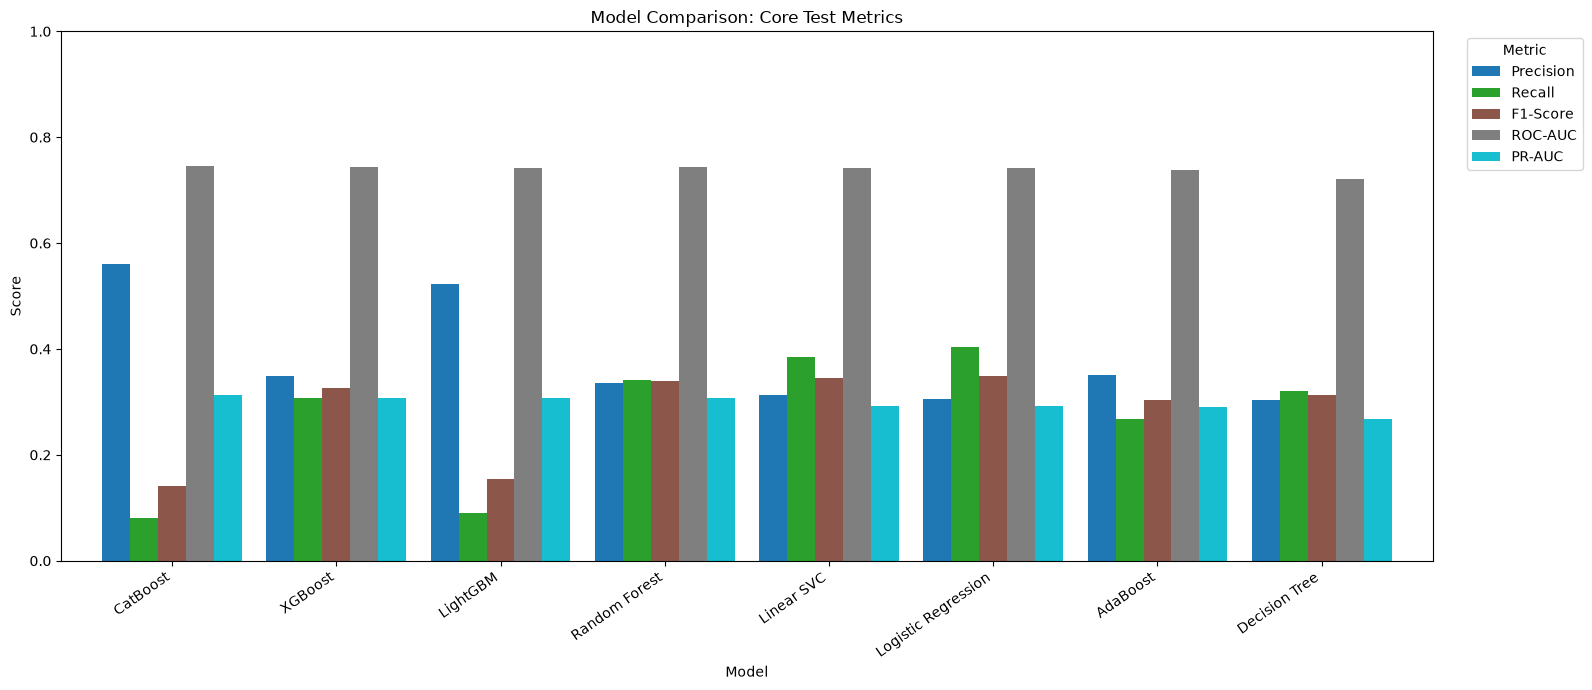

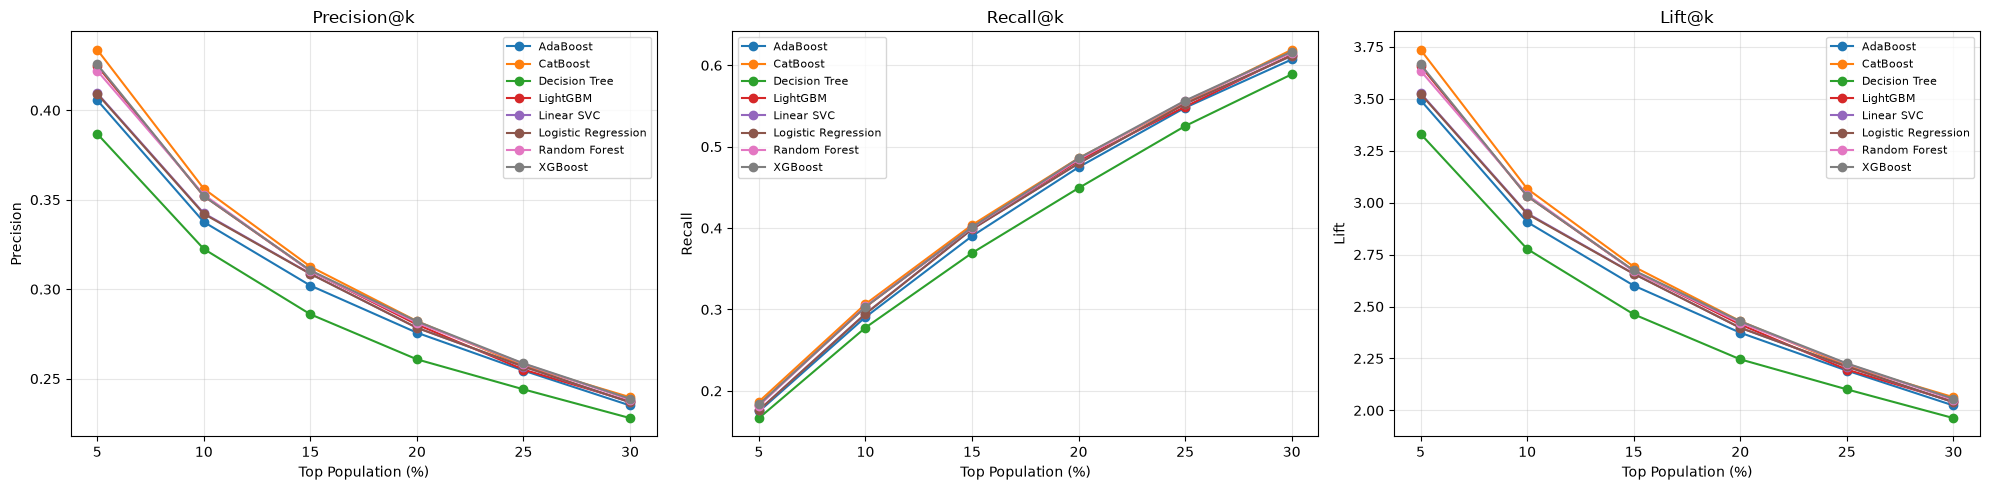

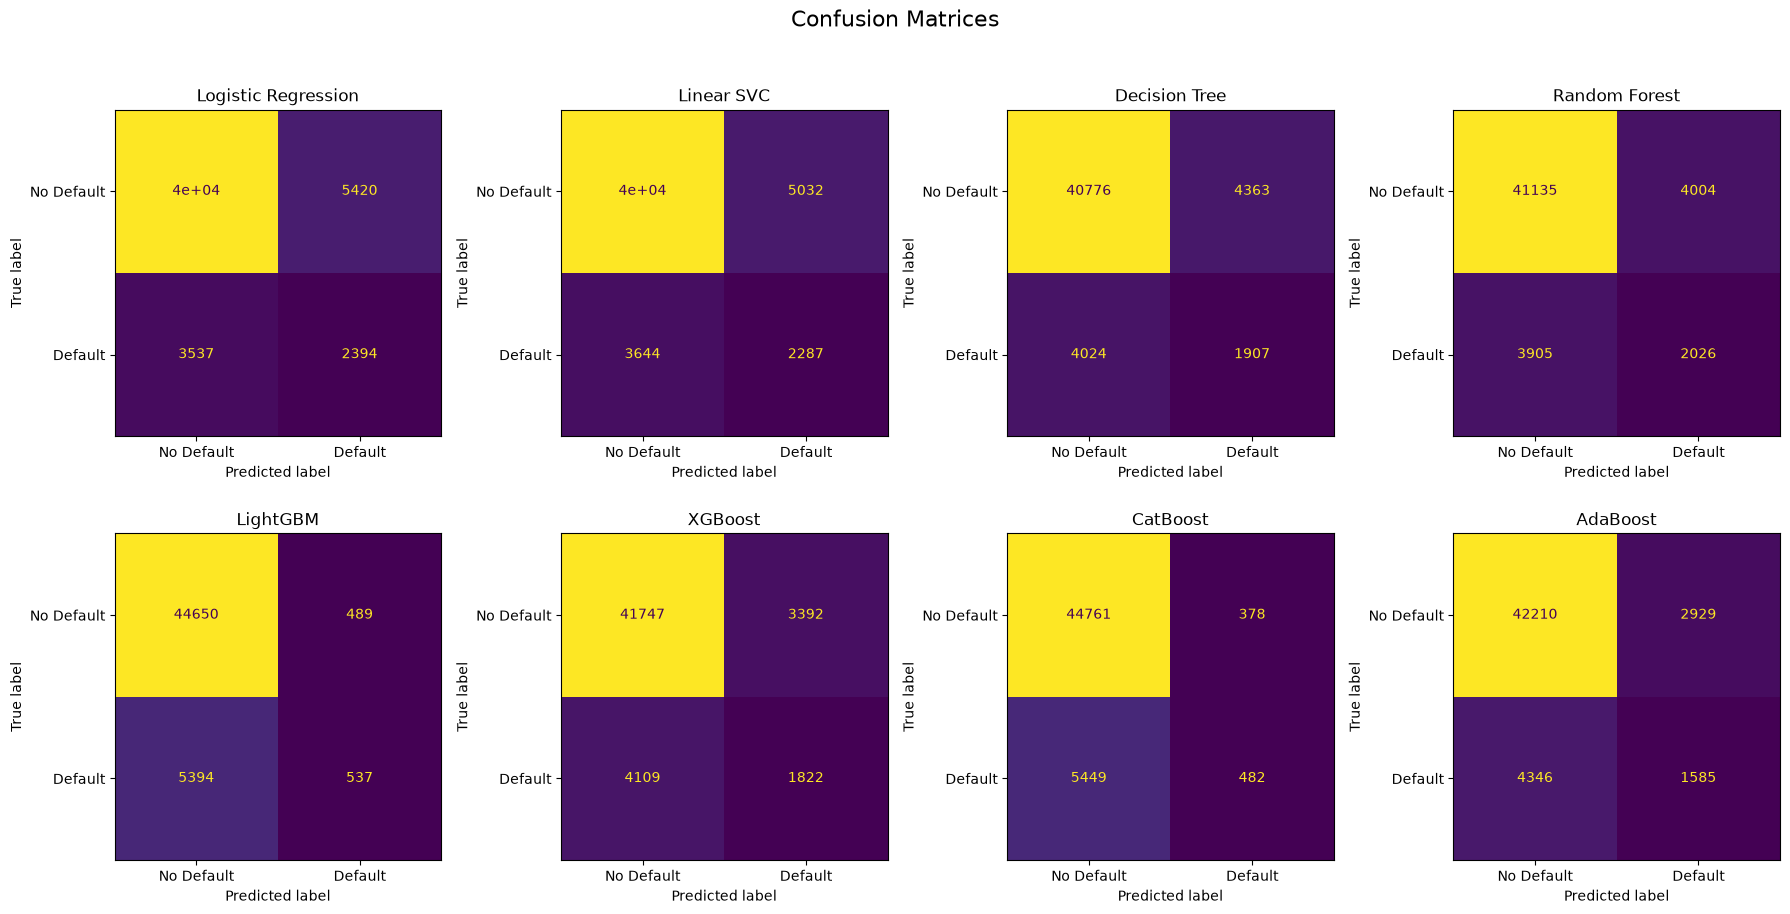

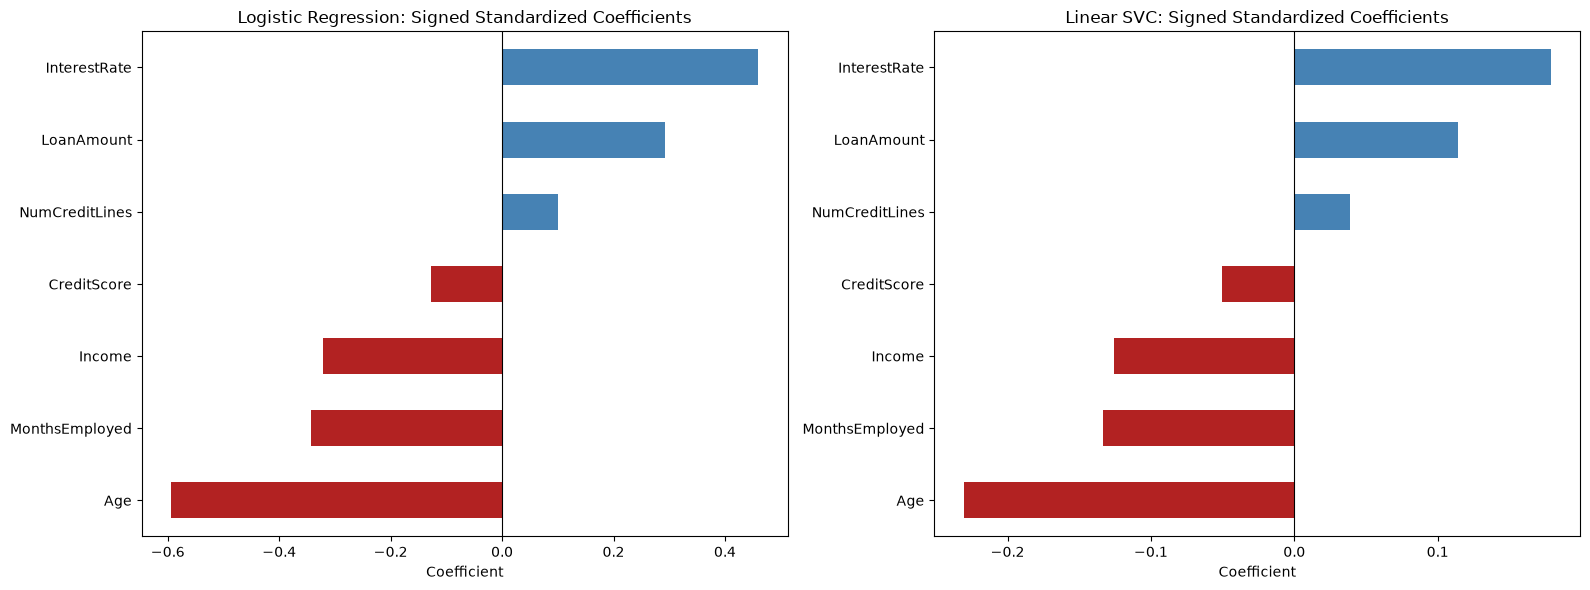

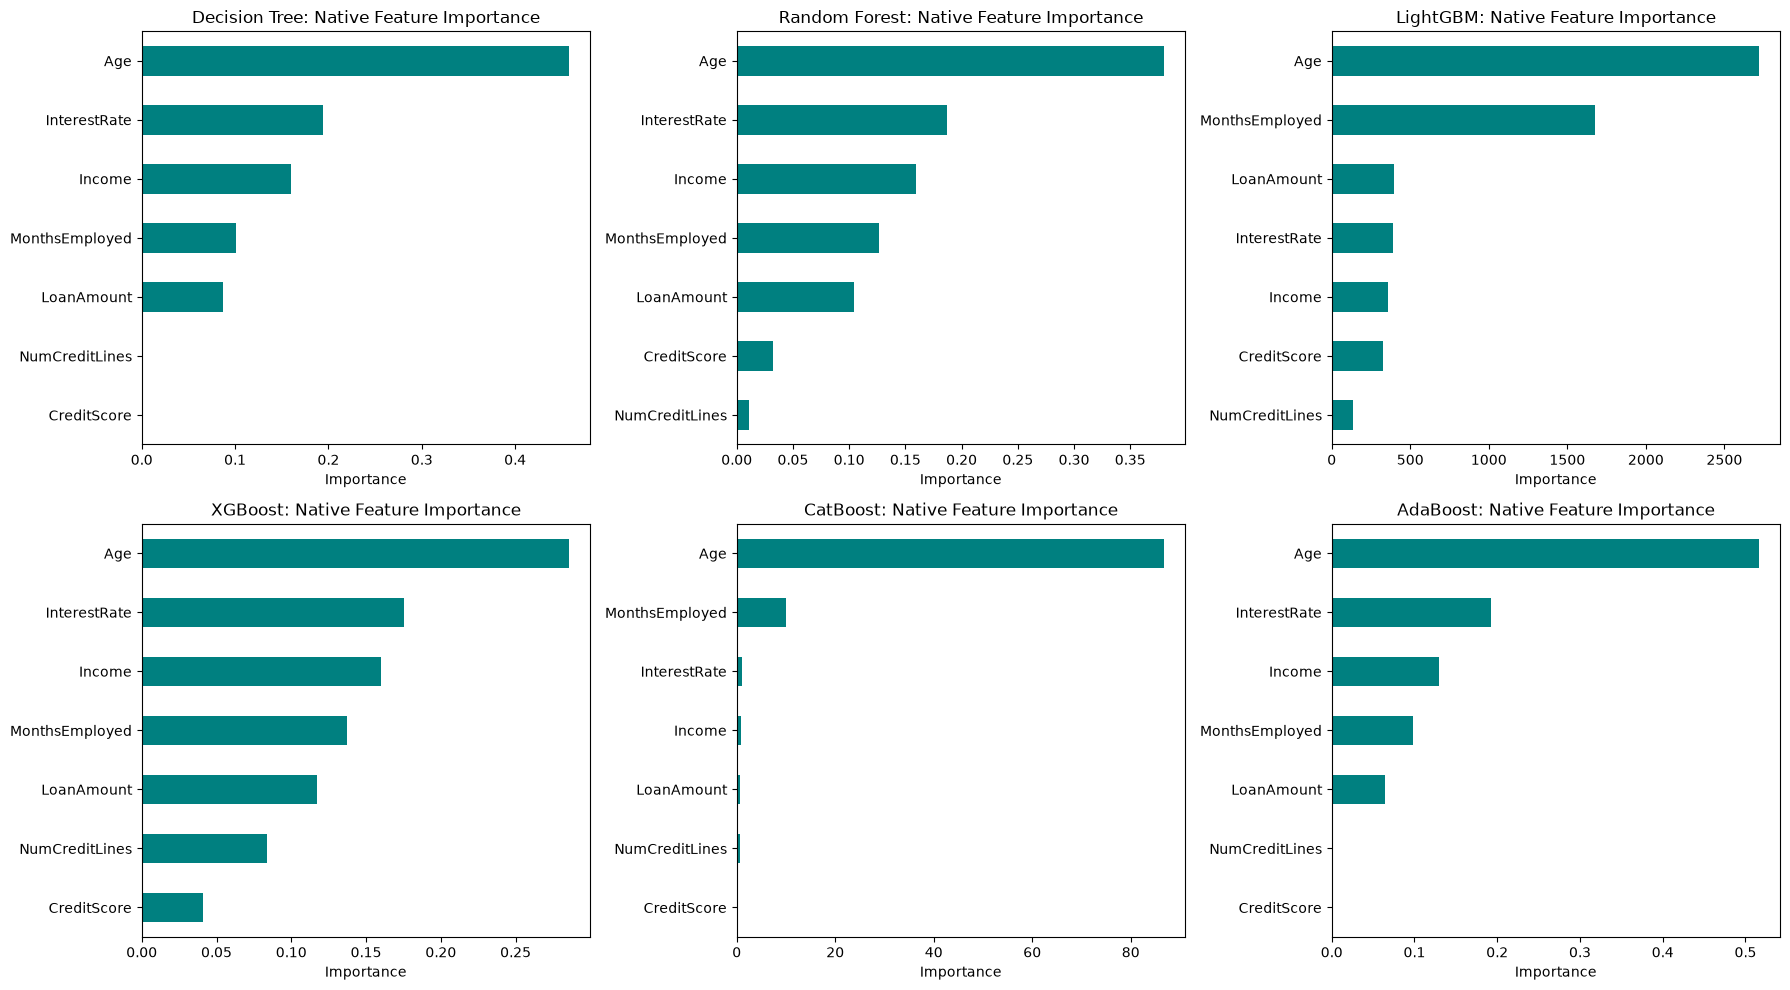

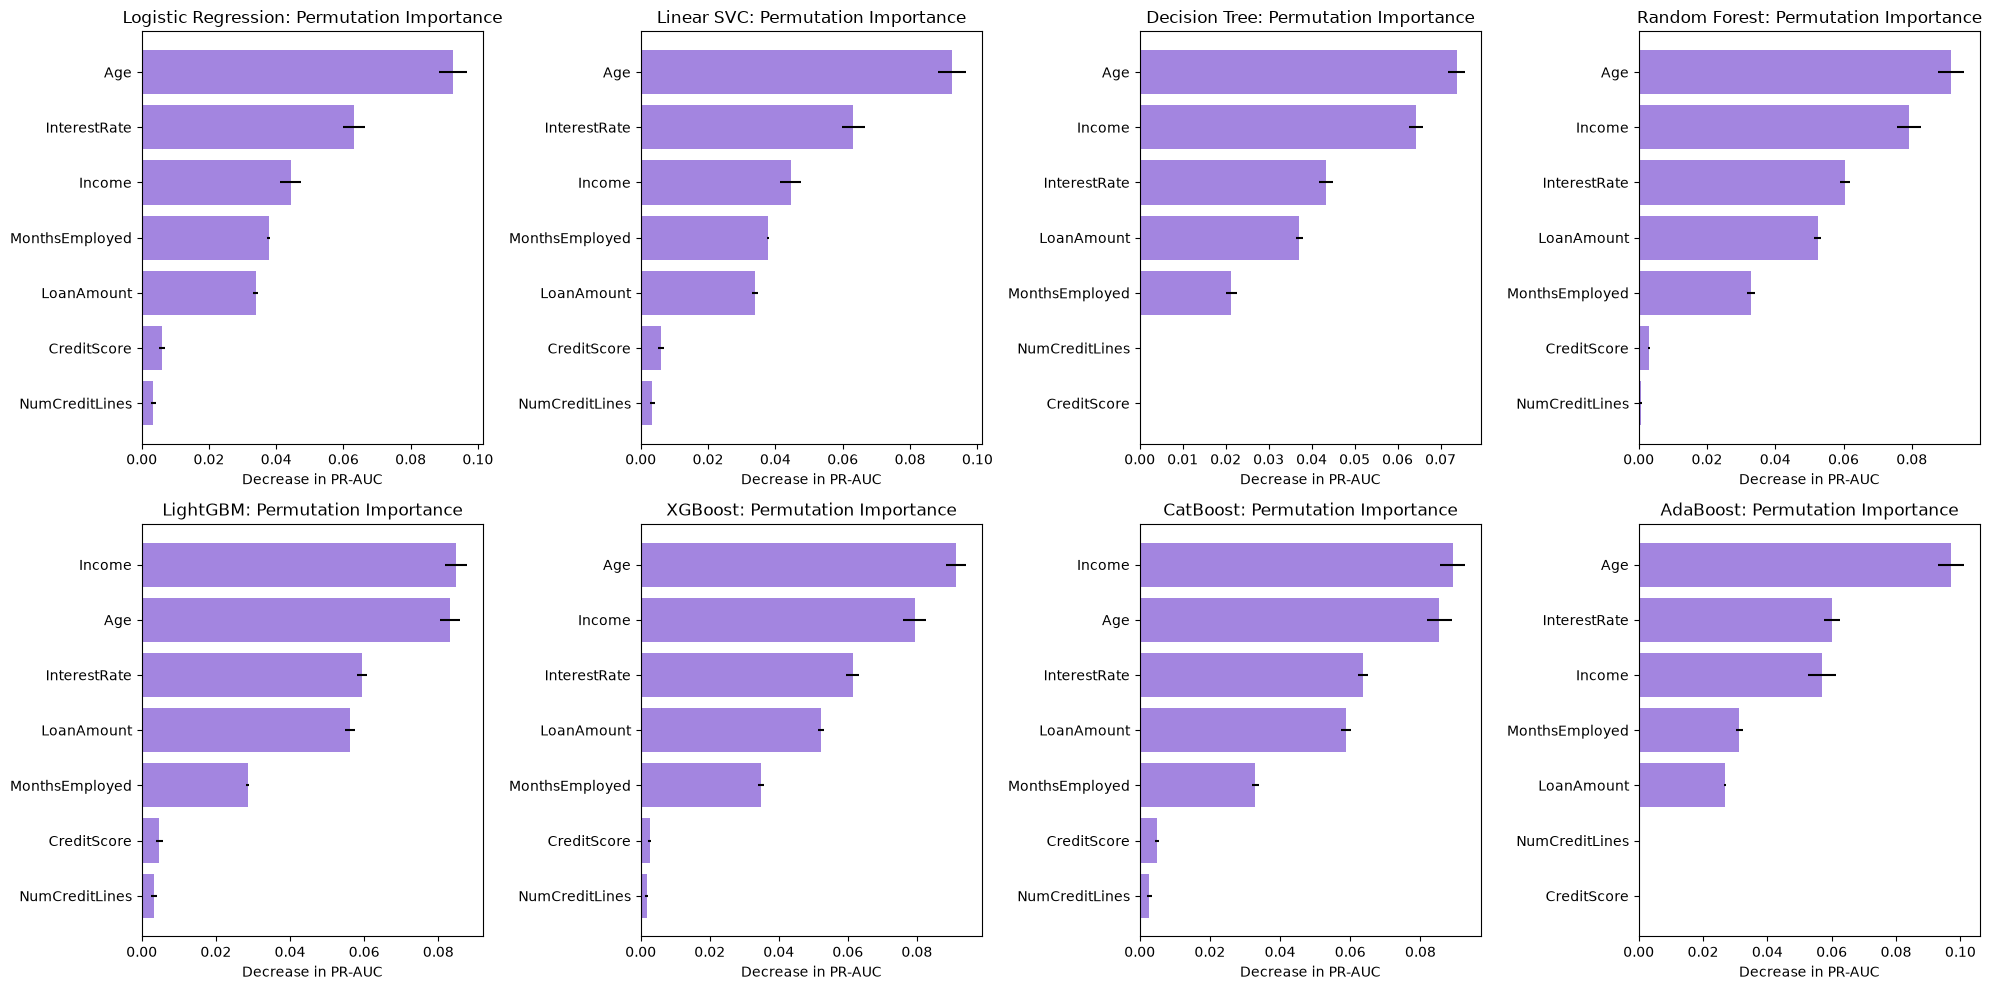


FINAL RANKING — PRIMARY SORT: TEST PR-AUC


,Model,PR-AUC,ROC-AUC,Precision,Recall,F1-Score,Predicted Positive Rate,CV PR-AUC,CV-to-Test PR-AUC Difference
0,CatBoost,0.313970,0.745315,0.560465,0.081268,0.141953,0.016840,0.301951,-0.012018
1,XGBoost,0.307344,0.743108,0.349444,0.307199,0.326963,0.102095,0.293656,-0.013688
2,LightGBM,0.307170,0.741918,0.523392,0.090541,0.154377,0.020090,0.296098,-0.011073
3,Random Forest,0.306462,0.742855,0.335987,0.341595,0.338768,0.118073,0.293492,-0.012970
4,Linear SVC,0.292387,0.741989,0.312474,0.385601,0.345208,0.143313,0.285631,-0.006756
5,Logistic Regression,0.292317,0.741998,0.306373,0.403642,0.348345,0.153006,0.285566,-0.006751
6,AdaBoost,0.290510,0.737820,0.351130,0.267240,0.303494,0.088388,0.280739,-0.009771
7,Decision Tree,0.267621,0.720139,0.304147,0.321531,0.312597,0.122773,0.256119,-0.011501



Operational interpretation: Precision@k measures the default rate among the highest-risk applicants selected for action, while Recall@k measures the share of all defaults captured. Increasing k generally captures more defaults (higher recall) but lowers precision and lift. Model selection should prioritize PR-AUC and business capacity rather than ROC-AUC alone.


In [6]:
import numpy as np
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)

k_values = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
test_default_rate = y_test.mean()

evaluation_results = []
ranking_curves = []
permutation_results = []

for model_name, fitted_pipeline in best_models.items():
    if hasattr(fitted_pipeline, "predict_proba"):
        scores = fitted_pipeline.predict_proba(X_test)[:, 1]
    else:
        scores = fitted_pipeline.decision_function(X_test)

    predictions = fitted_pipeline.predict(X_test)

    model_metrics = {
        "Model": model_name,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, scores),
        "PR-AUC": average_precision_score(y_test, scores),
        "Predicted Positive Rate": predictions.mean()
    }

    print(f"\n{'=' * 70}\n{model_name}")
    print(f"Precision: {model_metrics['Precision']:.4f}")
    print(f"Recall:    {model_metrics['Recall']:.4f}")
    print(f"F1-Score:  {model_metrics['F1-Score']:.4f}")
    print(f"ROC-AUC:   {model_metrics['ROC-AUC']:.4f}")
    print(f"PR-AUC:    {model_metrics['PR-AUC']:.4f}")

    ranked_indices = np.argsort(-scores)

    for k in k_values:
        top_n = int(np.ceil(len(y_test) * k))
        top_k_actuals = y_test.iloc[ranked_indices[:top_n]]

        precision_at_k = top_k_actuals.mean()
        recall_at_k = top_k_actuals.sum() / y_test.sum()
        lift_at_k = precision_at_k / test_default_rate

        label = f"{int(k * 100)}%"
        model_metrics[f"Precision@{label}"] = precision_at_k
        model_metrics[f"Recall@{label}"] = recall_at_k
        model_metrics[f"Lift@{label}"] = lift_at_k

        ranking_curves.append({
            "Model": model_name,
            "Top Population (%)": int(k * 100),
            "Precision@k": precision_at_k,
            "Recall@k": recall_at_k,
            "Lift@k": lift_at_k
        })

    evaluation_results.append(model_metrics)

    print("Calculating permutation importance...")
    permutation = permutation_importance(
        fitted_pipeline,
        X_test,
        y_test,
        scoring="average_precision",
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    permutation_results.append(
        pd.DataFrame({
            "Model": model_name,
            "Feature": selected_features,
            "Importance Mean": permutation.importances_mean,
            "Importance Std": permutation.importances_std
        })
    )

evaluation_df = (
    pd.DataFrame(evaluation_results)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

model_selection_df = (
    results_df[
        ["Model", "Best Hyperparameters", "CV PR-AUC", "CV PR-AUC Std",
         "Training Time (sec)", "Test PR-AUC", "Test ROC-AUC"]
    ]
    .copy()
)

model_selection_df["CV-to-Test PR-AUC Difference"] = (
    model_selection_df["CV PR-AUC"] - model_selection_df["Test PR-AUC"]
)

permutation_importance_df = pd.concat(permutation_results, ignore_index=True)
ranking_curves_df = pd.DataFrame(ranking_curves)

print("\nMASTER EVALUATION RESULTS")
display(evaluation_df)

print("\nBEST PARAMETERS AND CV RESULTS")
display(model_selection_df.sort_values("Test PR-AUC", ascending=False))

# Grouped bar chart of core metrics
core_metrics = ["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]
plot_metrics = evaluation_df.set_index("Model")[core_metrics]

ax = plot_metrics.plot(
    kind="bar",
    figsize=(16, 7),
    width=0.85,
    colormap="tab10"
)
ax.set_title("Model Comparison: Core Test Metrics")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0, 1)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Ranking performance curves
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for model_name, group in ranking_curves_df.groupby("Model"):
    group = group.sort_values("Top Population (%)")
    axes[0].plot(group["Top Population (%)"], group["Precision@k"], marker="o", label=model_name)
    axes[1].plot(group["Top Population (%)"], group["Recall@k"], marker="o", label=model_name)
    axes[2].plot(group["Top Population (%)"], group["Lift@k"], marker="o", label=model_name)

axes[0].set_title("Precision@k")
axes[1].set_title("Recall@k")
axes[2].set_title("Lift@k")

for axis in axes:
    axis.set_xlabel("Top Population (%)")
    axis.grid(alpha=0.3)
    axis.legend(fontsize=8)

axes[0].set_ylabel("Precision")
axes[1].set_ylabel("Recall")
axes[2].set_ylabel("Lift")

plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for axis, (model_name, fitted_pipeline) in zip(axes, best_models.items()):
    model_predictions = fitted_pipeline.predict(X_test)
    matrix = confusion_matrix(y_test, model_predictions)

    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["No Default", "Default"]
    ).plot(ax=axis, colorbar=False)

    axis.set_title(model_name)

plt.suptitle("Confusion Matrices", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Signed standardized coefficients for linear models
linear_models = ["Logistic Regression", "Linear SVC"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for axis, model_name in zip(axes, linear_models):
    fitted_model = best_models[model_name].named_steps["model"]
    coefficients = pd.Series(
        fitted_model.coef_.ravel(),
        index=selected_features
    ).sort_values()

    colors = np.where(coefficients >= 0, "steelblue", "firebrick")
    coefficients.plot(kind="barh", ax=axis, color=colors)

    axis.axvline(0, color="black", linewidth=0.8)
    axis.set_title(f"{model_name}: Signed Standardized Coefficients")
    axis.set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

# Native feature importance for tree and boosting models
tree_boost_models = [
    "Decision Tree", "Random Forest", "LightGBM",
    "XGBoost", "CatBoost", "AdaBoost"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for axis, model_name in zip(axes, tree_boost_models):
    fitted_model = best_models[model_name].named_steps["model"]

    importance = pd.Series(
        fitted_model.feature_importances_,
        index=selected_features
    ).sort_values()

    importance.plot(kind="barh", ax=axis, color="teal")
    axis.set_title(f"{model_name}: Native Feature Importance")
    axis.set_xlabel("Importance")

plt.tight_layout()
plt.show()

# Permutation importance for every model
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for axis, model_name in zip(axes, best_models):
    importance_data = (
        permutation_importance_df[
            permutation_importance_df["Model"] == model_name
        ]
        .sort_values("Importance Mean")
    )

    axis.barh(
        importance_data["Feature"],
        importance_data["Importance Mean"],
        xerr=importance_data["Importance Std"],
        color="mediumpurple",
        alpha=0.85
    )
    axis.set_title(f"{model_name}: Permutation Importance")
    axis.set_xlabel("Decrease in PR-AUC")

plt.tight_layout()
plt.show()

final_comparison_df = (
    evaluation_df
    .merge(
        model_selection_df[
            ["Model", "CV PR-AUC", "CV-to-Test PR-AUC Difference"]
        ],
        on="Model",
        how="left"
    )
    .sort_values(["PR-AUC", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

print("\nFINAL RANKING — PRIMARY SORT: TEST PR-AUC")
display(
    final_comparison_df[
        ["Model", "PR-AUC", "ROC-AUC", "Precision", "Recall",
         "F1-Score", "Predicted Positive Rate",
         "CV PR-AUC", "CV-to-Test PR-AUC Difference"]
    ]
)

print(
    "\nOperational interpretation: Precision@k measures the default rate among "
    "the highest-risk applicants selected for action, while Recall@k measures "
    "the share of all defaults captured. Increasing k generally captures more "
    "defaults (higher recall) but lowers precision and lift. Model selection "
    "should prioritize PR-AUC and business capacity rather than ROC-AUC alone."
)

In [8]:
import pickle

best_metrics = results_df.loc[results_df["Test PR-AUC"].idxmax()]
best_model_name = best_metrics["Model"]
best_model = best_models[best_model_name]
model_file = "best_credit_risk_model.pkl"

with open(model_file, "wb") as file:
    pickle.dump(best_model, file)

print(f"Saved best model to: {model_file}")
print(f"Model selected by Test PR-AUC: {best_model_name}")
print(f"Best hyperparameters: {best_metrics['Best Hyperparameters']}")
print(f"CV PR-AUC: {best_metrics['CV PR-AUC']:.4f}")
print(f"Test PR-AUC: {best_metrics['Test PR-AUC']:.4f}")
print(f"Test ROC-AUC: {best_metrics['Test ROC-AUC']:.4f}")
print(f"Test precision: {best_metrics['Test Precision']:.4f}")
print(f"Test recall: {best_metrics['Test Recall']:.4f}")
print(f"Test F1-score: {best_metrics['Test F1-Score']:.4f}")


Saved best model to: best_credit_risk_model.pkl
Model selected by Test PR-AUC: CatBoost
Best hyperparameters: {'model__depth': 6, 'model__iterations': 200, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.1}
CV PR-AUC: 0.3020
Test PR-AUC: 0.3140
Test ROC-AUC: 0.7453
Test precision: 0.5605
Test recall: 0.0813
Test F1-score: 0.1420
